Importações de Bibliotecas

In [329]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import io, os, random

In [330]:
dados = pd.read_csv('../Prata.csv', sep=';', encoding='utf-8', decimal=',')
dados.tail(20)

,data_Lançamento,1. Pessoal Ativo,2. Pessoal Inativo e Pensionistas,4. Indenizações por Demissão e Incentivo à Demissão,5. Decorrentes de Decisão Judicial,6. Despesas de Exercicios Anteriores,7. Inativos e Pensionistas com Recursos Vinculados,9. Receita Corrente,10. Deduções
127,08-2024,9.159031e+08,6.669900e+08,997281.2,0.0,800581.2,1.918020e+08,4.753895e+09,1.239725e+09
128,09-2024,9.654408e+08,6.675743e+08,1184812.0,0.0,1038322.4,2.182234e+08,4.603217e+09,1.194247e+09
129,10-2024,1.148392e+09,6.815468e+08,1746846.7,63971.1,2178769.0,2.227669e+08,4.623710e+09,1.437768e+09
130,11-2024,9.434185e+08,5.868478e+08,819858.6,0.0,2992505.0,2.232093e+08,4.957853e+09,1.280028e+09
131,12-2024,2.294684e+09,1.315921e+09,1166479.6,407623572.8,1215519.6,3.934379e+08,5.373587e+09,1.888398e+09
132,01-2025,1.007702e+09,6.708176e+08,NaN,NaN,NaN,2.204016e+08,5.652536e+09,1.155264e+09
133,02-2025,9.816163e+08,6.751124e+08,NaN,NaN,NaN,2.054635e+08,5.687448e+09,1.634755e+09
134,03-2025,9.609695e+08,6.769911e+08,NaN,NaN,NaN,1.961541e+08,4.727752e+09,1.293003e+09
135,04-2025,9.602988e+08,6.766460e+08,NaN,NaN,NaN,2.038257e+08,4.871807e+09,1.375843e+09
136,05-2025,9.645936e+08,6.758968e+08,NaN,NaN,NaN,2.370245e+08,5.013924e+09,1.361954e+09


In [331]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 9 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   data_Lançamento                                      147 non-null    object 
 1   1. Pessoal Ativo                                     146 non-null    float64
 2   2. Pessoal Inativo e Pensionistas                    146 non-null    float64
 3   4. Indenizações por Demissão e Incentivo à Demissão  132 non-null    float64
 4   5. Decorrentes de Decisão Judicial                   132 non-null    float64
 5   6. Despesas de Exercicios Anteriores                 132 non-null    float64
 6   7. Inativos e Pensionistas com Recursos Vinculados   146 non-null    float64
 7   9. Receita Corrente                                  135 non-null    float64
 8   10. Deduções                                         135 non-null    fl

In [332]:
dados['Data'] = pd.to_datetime(dados['data_Lançamento'], format='%m-%Y')

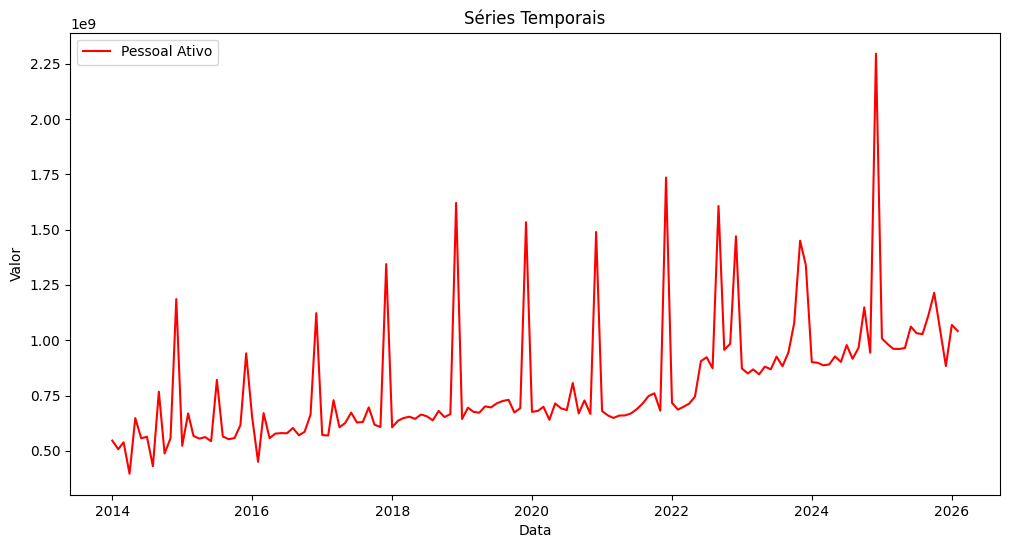

In [333]:
plt.figure(figsize=(12, 6))

plt.plot('Data', '1. Pessoal Ativo', data=dados, label='Pessoal Ativo',  linestyle='-', color='red')
plt.title('Séries Temporais')
plt.legend() 
plt.xlabel('Data')
plt.ylabel('Valor')
plt.show()

In [334]:
PA = pd.DataFrame(dados[['Data','1. Pessoal Ativo']])
PA = PA.dropna()

Tratamento de Outlayers

In [335]:
teto = PA['1. Pessoal Ativo'].quantile(0.95) # Pega o valor que representa os 95% maiores dados
# Tudo o que for maior que o teto, vira o teto. O que for menor, continua igual.
PA['1. Pessoal Ativo'] = np.clip(PA['1. Pessoal Ativo'], a_min=None, a_max=teto)

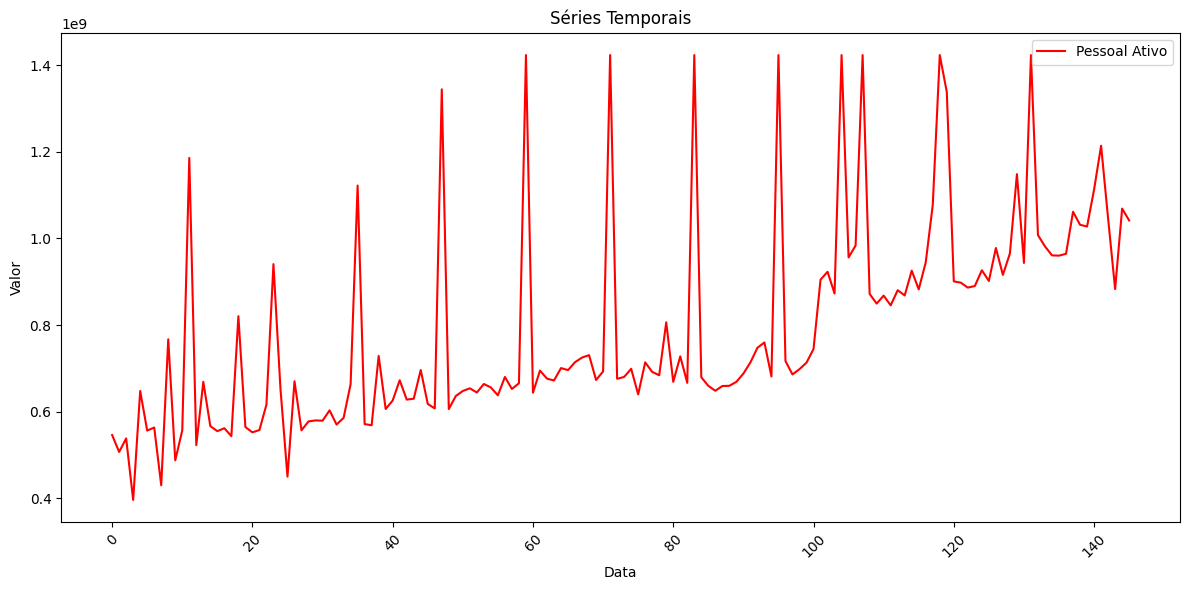

In [336]:
plt.figure(figsize=(12, 6))

plt.plot(PA.index, PA['1. Pessoal Ativo'], label='Pessoal Ativo', linestyle='-', color='red')
plt.title('Séries Temporais')
plt.legend()
plt.xlabel('Data')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Gráficos ACF e PACF: Pessoal Ativo

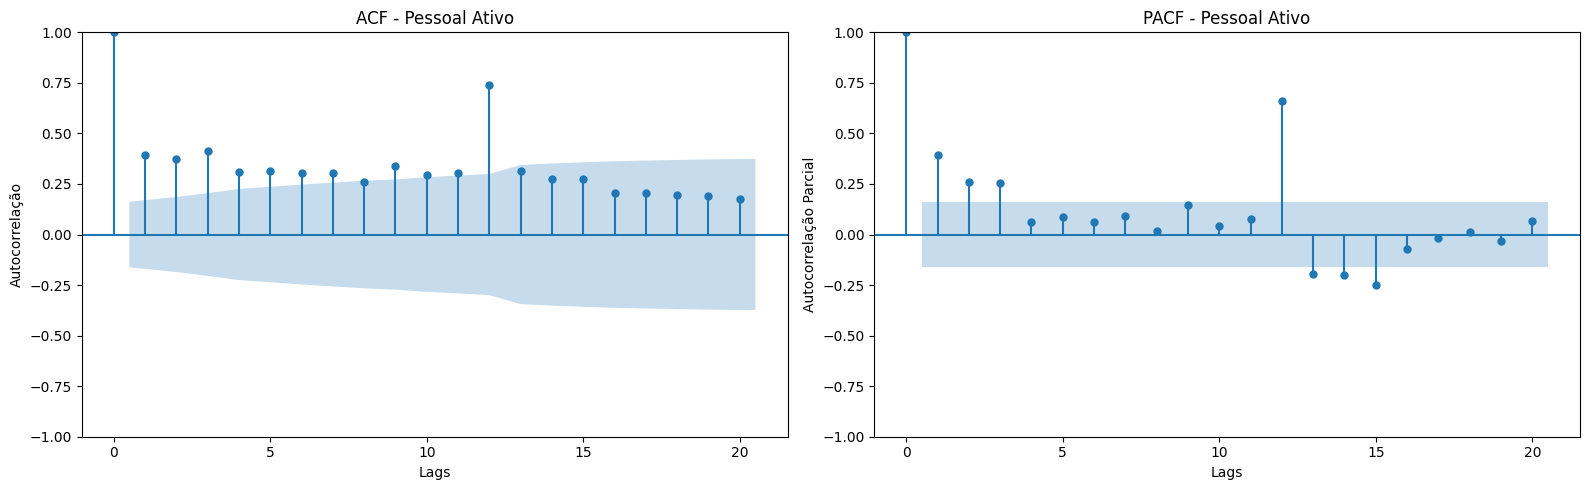

In [337]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(PA['1. Pessoal Ativo'], ax=axes[0], lags=20)
axes[0].set_title('ACF - Pessoal Ativo')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelação')  
plot_pacf(PA['1. Pessoal Ativo'], ax=axes[1], lags=20)
axes[1].set_title('PACF - Pessoal Ativo')   
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Autocorrelação Parcial')
plt.tight_layout()
plt.show()    


Crianção de Lags

In [338]:
PA.set_index('Data', inplace=True)
for i in range(1, 13):
    PA[f'Lag {i}'] = PA['1. Pessoal Ativo'].shift(i)
PA.dropna(inplace=True)

In [339]:
#PA.reset_index(drop=True, inplace=True)
PA.head()

,1. Pessoal Ativo,Lag 1,Lag 2,Lag 3,Lag 4,Lag 5,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12
Data,,,,,,,,,,,,,
2015-01-01,522976131.8,1.185804e+09,5.569715e+08,4.879371e+08,7.672038e+08,4.302337e+08,563626632.7,556555798.3,647862745.1,396504353.4,538507826.7,507208402.1,546275104.8
2015-02-01,669010895.0,5.229761e+08,1.185804e+09,5.569715e+08,4.879371e+08,7.672038e+08,430233726.7,563626632.7,556555798.3,647862745.1,396504353.4,538507826.7,507208402.1
2015-03-01,566806955.6,6.690109e+08,5.229761e+08,1.185804e+09,5.569715e+08,4.879371e+08,767203844.8,430233726.7,563626632.7,556555798.3,647862745.1,396504353.4,538507826.7
2015-04-01,555232514.6,5.668070e+08,6.690109e+08,5.229761e+08,1.185804e+09,5.569715e+08,487937141.0,767203844.8,430233726.7,563626632.7,556555798.3,647862745.1,396504353.4
2015-05-01,562013236.5,5.552325e+08,5.668070e+08,6.690109e+08,5.229761e+08,1.185804e+09,556971526.9,487937141.0,767203844.8,430233726.7,563626632.7,556555798.3,647862745.1


In [340]:
PA.tail(10)

,1. Pessoal Ativo,Lag 1,Lag 2,Lag 3,Lag 4,Lag 5,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12
Data,,,,,,,,,,,,,
2025-05-01,9.645936e+08,9.602988e+08,9.609695e+08,9.816163e+08,1.007702e+09,1.423207e+09,9.434185e+08,1.148392e+09,9.654408e+08,9.159031e+08,9.779277e+08,9.018303e+08,9.266026e+08
2025-06-01,1.061595e+09,9.645936e+08,9.602988e+08,9.609695e+08,9.816163e+08,1.007702e+09,1.423207e+09,9.434185e+08,1.148392e+09,9.654408e+08,9.159031e+08,9.779277e+08,9.018303e+08
2025-07-01,1.031537e+09,1.061595e+09,9.645936e+08,9.602988e+08,9.609695e+08,9.816163e+08,1.007702e+09,1.423207e+09,9.434185e+08,1.148392e+09,9.654408e+08,9.159031e+08,9.779277e+08
2025-08-01,1.027499e+09,1.031537e+09,1.061595e+09,9.645936e+08,9.602988e+08,9.609695e+08,9.816163e+08,1.007702e+09,1.423207e+09,9.434185e+08,1.148392e+09,9.654408e+08,9.159031e+08
2025-09-01,1.112812e+09,1.027499e+09,1.031537e+09,1.061595e+09,9.645936e+08,9.602988e+08,9.609695e+08,9.816163e+08,1.007702e+09,1.423207e+09,9.434185e+08,1.148392e+09,9.654408e+08
2025-10-01,1.213996e+09,1.112812e+09,1.027499e+09,1.031537e+09,1.061595e+09,9.645936e+08,9.602988e+08,9.609695e+08,9.816163e+08,1.007702e+09,1.423207e+09,9.434185e+08,1.148392e+09
2025-11-01,1.046065e+09,1.213996e+09,1.112812e+09,1.027499e+09,1.031537e+09,1.061595e+09,9.645936e+08,9.602988e+08,9.609695e+08,9.816163e+08,1.007702e+09,1.423207e+09,9.434185e+08
2025-12-01,8.831733e+08,1.046065e+09,1.213996e+09,1.112812e+09,1.027499e+09,1.031537e+09,1.061595e+09,9.645936e+08,9.602988e+08,9.609695e+08,9.816163e+08,1.007702e+09,1.423207e+09
2026-01-01,1.068828e+09,8.831733e+08,1.046065e+09,1.213996e+09,1.112812e+09,1.027499e+09,1.031537e+09,1.061595e+09,9.645936e+08,9.602988e+08,9.609695e+08,9.816163e+08,1.007702e+09


Dividindo entre treino e teste

In [341]:
y = PA['1. Pessoal Ativo'].values.reshape(-1, 1).astype(float)
X = PA.drop(columns=['1. Pessoal Ativo']).values.astype(float)

In [342]:
X.shape, y.shape

((134, 12), (134, 1))

In [343]:
PA.index[131]

Timestamp('2025-12-01 00:00:00')

In [344]:
#Treino
X_train = X[:120]
y_train = y[:120]

#Validação
X_val = X[120:132]
y_val = y[120:132]

#Teste
X_test = X[132:]
y_test = y[132:]

In [345]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape ,X_test.shape, y_test.shape, 

((120, 12), (120, 1), (12, 12), (12, 1), (2, 12), (2, 1))

Normalizando os Dados

In [346]:
# Scaler para as Features X
#scaler_X = MinMaxScaler()
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train) #treino
X_val_scaled = scaler_X.transform(X_val)   # validação
X_test_scaled = scaler_X.transform(X_test) # teste

# Scaler para o Alvo y
#scaler_y = MinMaxScaler()
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train) #treino
y_val_scaled = scaler_y.transform(y_val)   # validação
y_test_scaled = scaler_y.transform(y_test) # teste

In [347]:
print(f"Máximo no X do treino: {X_train_scaled.max()}, Mínimo: {X_train_scaled.min()}")
print(f"Máximo no X do validação: {X_val_scaled.max()}, Mínimo: {X_val_scaled.min()}")
print(f"Máximo no X do teste: {X_test_scaled.max()}, Mínimo: {X_test_scaled.min()}")
print("---------------------------------")
print(f"Máximo no y do treino: {y_train_scaled.max()}, Mínimo: {y_train_scaled.min()}")
print(f"Máximo no y do validação: {y_val_scaled.max()}, Mínimo: {y_val_scaled.min()}")
print(f"Máximo no y do teste: {y_test_scaled.max()}, Mínimo: {y_test_scaled.min()}")


Máximo no X do treino: 2.9627692359663143, Mínimo: -1.5534193797561247
Máximo no X do validação: 2.9627692359663143, Mínimo: 0.6027145738466256
Máximo no X do teste: 1.9824984996136614, Mínimo: 0.4621401771210018
---------------------------------
Máximo no y do treino: 2.783870768752815, Mínimo: -1.4308832380646594
Máximo no y do validação: 1.8775826844975754, Mínimo: 0.44447431824555295
Máximo no y do teste: 1.2487189999013373, Mínimo: 1.1305853860211859


Definição de Hiperparâmetros

In [348]:
hiperparametros = {
    'TAXA_DE_APRENDIZADO': 0.001,
    'EPOCAS': 100,
    'TAMANHO_LOTE': 64,
    'ENTRADAS': 32,
    'UNIDADES_OCULTAS': 16,
    'ATIVACAO': 'tanh',
    'RANDOM_STATE': 42,
    'VALIDACAO': (X_val_scaled, y_val_scaled),
    "DROPOUT_RATE": 0.2,
    "PATIENCE": 10
    
}

In [349]:
#Construção da arquitetura

# Garantindo a reprodutibilidade
os.environ['PYTHONHASHSEED'] = str(hiperparametros['RANDOM_STATE'])
random.seed(hiperparametros['RANDOM_STATE'])
np.random.seed(hiperparametros['RANDOM_STATE'])
tf.random.set_seed(hiperparametros['RANDOM_STATE'])


#Camada de Entrada
model_mlp = Sequential([Dense(hiperparametros['ENTRADAS'], # 64 Neurônio nesta camada (Z = W*X + b)
                                  input_shape=(X_train_scaled.shape[1],), # Quantidade de variáveis que vão entrar ( Z = w1*x1 + w2*x2 + b)
                                  activation=hiperparametros['ATIVACAO']) ]) # Especificando qual vai ser o tipo de ativação. Ex: reLu, linear, tanh, sigmoid...

#Dropout entre as camadas para evitar overfitting
#model_mlp.add(Dropout(hiperparametros['DROPOUT_RATE'])) # Adiciona uma camada de Dropout para ajudar a prevenir overfitting, desligando aleatoriamente 20% dos neurônios durante o treinamento

#Camada Oculta 1
model_mlp.add(Dense(hiperparametros['UNIDADES_OCULTAS'], activation=hiperparametros['ATIVACAO']))

#Dropout entre as camadas para evitar overfitting
#model_mlp.add(Dropout(hiperparametros['DROPOUT_RATE'])) # Adiciona uma camada de Dropout para ajudar a prevenir overfitting, desligando aleatoriamente 20% dos neurônios durante o treinamento

#Camada de Saída
model_mlp.add(Dense(1, activation='linear')) # 1 Neurônio nesta camada (Z = W*X + b) 


#Configuração
model_mlp.compile(
    optimizer=Adam(learning_rate=hiperparametros['TAXA_DE_APRENDIZADO']), #Aplicação do modelo de Gradiente descendente, usando o leanning rate proposto
    loss='mse', # Qual a função da loss. Nesse caso o mse é (Z - F(x1,x2))²
    metrics=['mae'] # Erro Médio Absoluto para termos uma métrica mais legível
)


## Define a regra de parada
parada_antecipada = EarlyStopping(
    monitor='val_loss', # Fica de olho no erro de validação
    patience=hiperparametros['PATIENCE'],        # Se o erro não cair por 10 épocas seguidas, ele para
    restore_best_weights=True # Garante que você ficará com os melhores pesos encontrados
)



#Treinamento
historico = model_mlp.fit(
    X_train_scaled, y_train_scaled, #Indica quais são as bases
    epochs=hiperparametros['EPOCAS'], 
    batch_size=hiperparametros['TAMANHO_LOTE'], #O batch_size é a batelada de cada iteração (epoch) que será calculada
    validation_data=hiperparametros['VALIDACAO'], #Indica qual é a base de validação
    shuffle=False, # Manter a ordem temporal dos dados
    verbose=1, # Mude para 1 se quiser ver o log de cada época,
    callbacks=[parada_antecipada] # Early Stopping para evitar overfitting
)

Epoch 1/100


c:\Projeto Series Temporais\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - loss: 1.1481 - mae: 0.8679 - val_loss: 0.5556 - val_mae: 0.5848
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 1.0453 - mae: 0.8242 - val_loss: 0.4874 - val_mae: 0.5512
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.9548 - mae: 0.7831 - val_loss: 0.4314 - val_mae: 0.5194
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.8735 - mae: 0.7432 - val_loss: 0.3870 - val_mae: 0.4900
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.8004 - mae: 0.7044 - val_loss: 0.3526 - val_mae: 0.4656
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.7348 - mae: 0.6677 - val_loss: 0.3263 - val_mae: 0.4494
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.6760 - mae: 0.6340 - val_loss: 0.3064 - val_mae: 0.4348
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.6233 - mae: 0.6031 - val_loss: 0.2916 - val_mae: 0.4217
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.5760 - mae: 0.5740 - va

In [350]:
model_mlp.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,885 (11.27 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,924 (7.52 KB)

In [351]:
# get_weights() retorna uma lista: o primeiro item é a matriz de pesos (W), o segundo é o viés (b)
pesos, vies = model_mlp.get_layer(index=0).get_weights()

print(f"pesos: {pesos.flatten()} e o viés: {vies[0]:.4f}")

pesos: [ 0.28434706  0.10438051 -0.08485603  0.31171855 -0.33281827  0.13069397
  0.32700643 -0.2643962   0.03400813  0.078495   -0.3204793  -0.02282405
  0.3250748  -0.00315921  0.02373417  0.17430574 -0.3377887  -0.20817892
 -0.01166053 -0.30107182 -0.32410476  0.24095945  0.29762253 -0.1555596
  0.28614074 -0.29270884 -0.04356726  0.06367876  0.05195199 -0.2408689
 -0.2034357   0.3755646  -0.26527858 -0.06569622 -0.15053162 -0.30254528
  0.14816633 -0.21305534  0.11071906  0.08882339 -0.31674027  0.02422675
 -0.14398973 -0.05950998  0.31115162 -0.04307995  0.0314603  -0.20207474
 -0.25749883  0.18239786  0.06393798  0.02688465 -0.32652143 -0.30147028
  0.21196954  0.29225144 -0.02919795 -0.16144139 -0.36708766 -0.3189913
  0.20277055  0.22043711 -0.09421637  0.16475981 -0.12318671  0.2274381
 -0.11455144 -0.06486887  0.24028513  0.2563348   0.12679292  0.27457455
  0.27587846 -0.21122007  0.09965077 -0.31402788  0.31255117  0.18055269
  0.06791946 -0.24980932 -0.19747432  0.34771293

In [352]:
#data_min = scaler_X.data_min_
#scale = scaler_X.scale_

# w = pesos / scale (scale is the range: 1/(max - min))
#w = pesos / scale[:, np.newaxis]
#b_raw = vies - np.dot(data_min, w)

#w_escalar = w[0][0]
#b_raw_escalar = b_raw[0]

#print(f"Pesos desnormalizados: {w.flatten()}")
#print(f"Viés desnormalizado: {b_raw_escalar:.4f}")

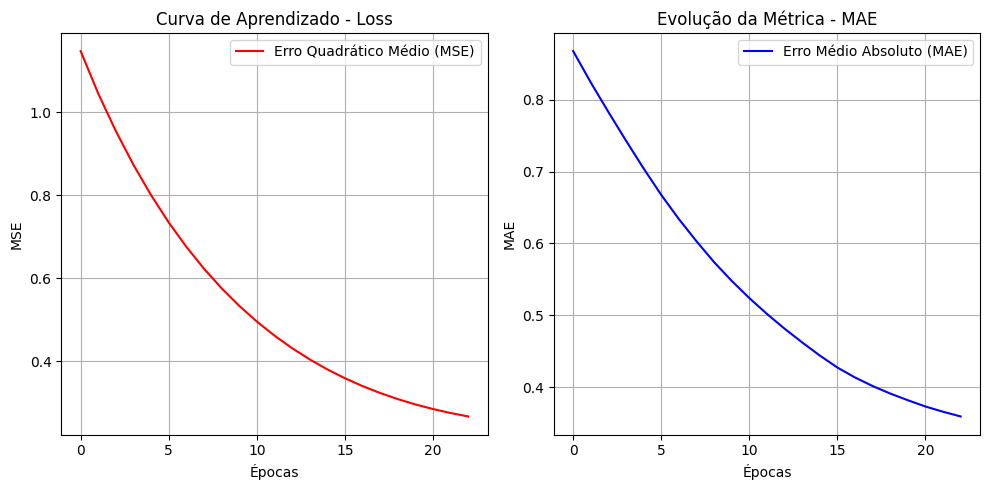

In [353]:
plt.figure(figsize=(10, 5))

# Plotando a Perda (MSE)
plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Erro Quadrático Médio (MSE)', color='red')
plt.title('Curva de Aprendizado - Loss')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# Plotando a Métrica (MAE)
plt.subplot(1, 2, 2)
plt.plot(historico.history['mae'], label='Erro Médio Absoluto (MAE)', color='blue')
plt.title('Evolução da Métrica - MAE')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [354]:
erro_simples = model_mlp.evaluate(X_test_scaled, y_test_scaled, verbose=0)[1]
print(f"Erro Médio Absoluto (Simples): {erro_simples:.2f}\n")

Erro Médio Absoluto (Simples): 0.07



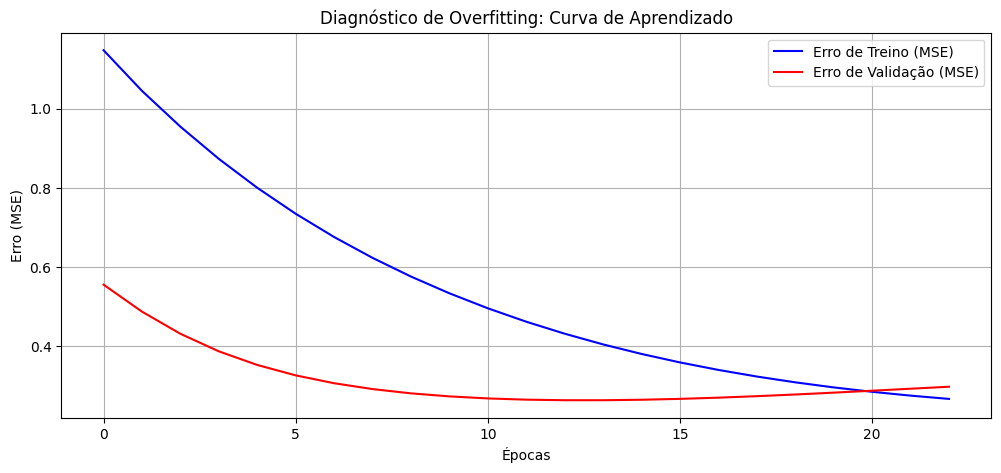

In [355]:
# Criando a figura para as curvas de perda (Loss)
plt.figure(figsize=(12, 5))

# Plotando a Perda de Treino
plt.plot(historico.history['loss'], label='Erro de Treino (MSE)', color='blue')

# Plotando a Perda de Validação (se você passou validation_data no fit)
if 'val_loss' in historico.history:
    plt.plot(historico.history['val_loss'], label='Erro de Validação (MSE)', color='red')

plt.title('Diagnóstico de Overfitting: Curva de Aprendizado')
plt.xlabel('Épocas')
plt.ylabel('Erro (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [356]:
epoca_restaurada = parada_antecipada.best_epoch + 1

print(f"Época usada:{epoca_restaurada}")

Época usada:13


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
--- Desempenho no Teste (Escala Original) ---
MAE (Erro Médio Absoluto): 16580058.0250
RMSE (Raiz do Erro Quadrático): 19015437.8784


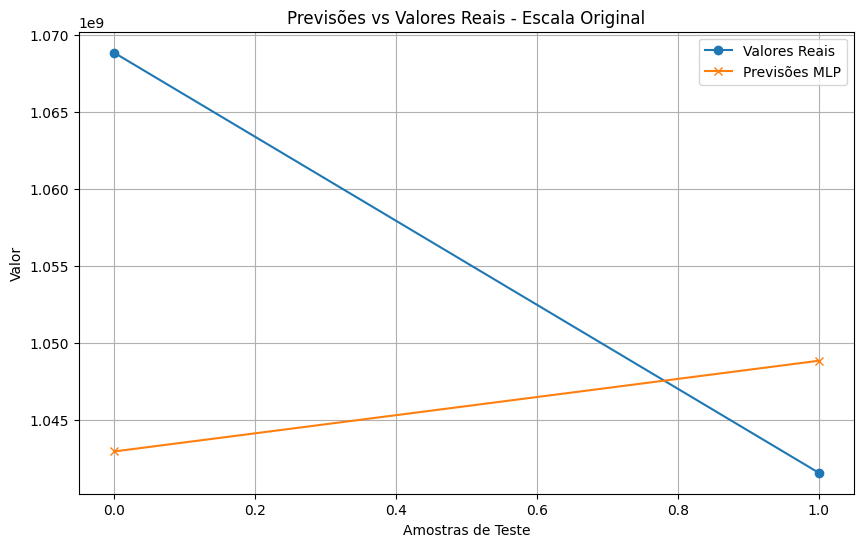

In [357]:
# Fazer as previsões usando o X de teste normalizado
y_pred_scaled = model_mlp.predict(X_test_scaled)

# Desfazer a normalização das previsões e dos valores reais
y_pred_original = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test_scaled) # ou apenas use o seu y_test original

# Calcular as métricas na escala real do negócio
mae_real = mean_absolute_error(y_test_original, y_pred_original)
mse_real = mean_squared_error(y_test_original, y_pred_original)
rmse_real = np.sqrt(mse_real)

print(f"--- Desempenho no Teste (Escala Original) ---")
print(f"MAE (Erro Médio Absoluto): {mae_real:.4f}")
print(f"RMSE (Raiz do Erro Quadrático): {rmse_real:.4f}")

# 4. Plotar o gráfico com os dados reais
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='Valores Reais', marker='o', color='tab:blue')
plt.plot(y_pred_original, label='Previsões MLP', marker='x', color='tab:orange')

plt.title('Previsões vs Valores Reais - Escala Original')
plt.xlabel('Amostras de Teste')
plt.ylabel('Valor') # Aqui os valores estarão na sua grandeza original (R$, quantidades, etc.)
plt.legend()
plt.grid(True)
plt.show()

--- ANO DE 2026 COMPLETO (TESTE + RECURSIVO) ---
Jan/2026: 1,042,936,832.00 (Teste)
Fev/2026: 1,048,826,624.00 (Teste)
Mar/2026: 1,048,826,560.00 (Recursivo)
Abr/2026: 1,043,034,816.00 (Recursivo)
Mai/2026: 1,018,407,936.00 (Recursivo)
Jun/2026: 1,051,873,536.00 (Recursivo)
Jul/2026: 1,068,580,416.00 (Recursivo)
Ago/2026: 1,078,466,944.00 (Recursivo)
Set/2026: 1,067,738,944.00 (Recursivo)
Out/2026: 1,061,821,760.00 (Recursivo)
Nov/2026: 1,073,905,280.00 (Recursivo)
Dez/2026: 1,084,007,680.00 (Recursivo)


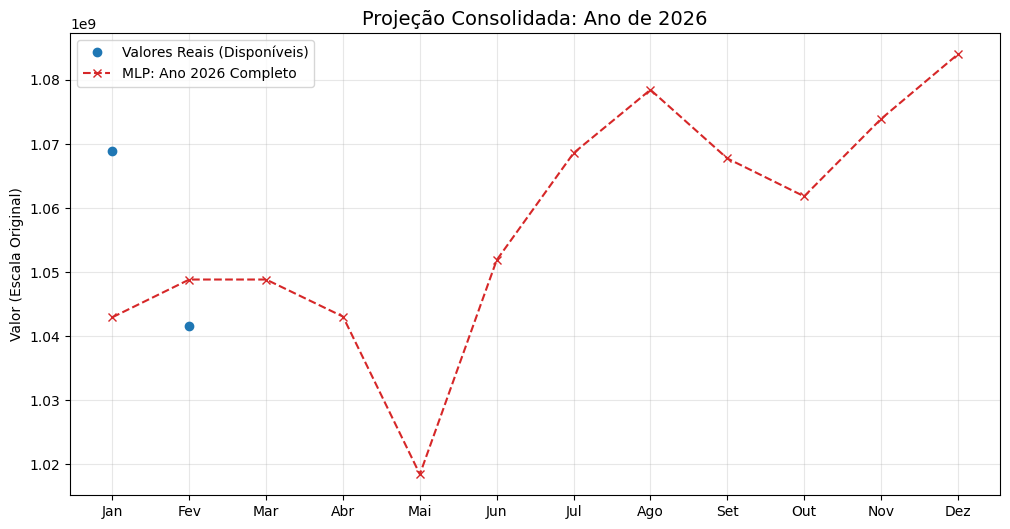

In [358]:
# --- 1. DEFINIÇÃO DO PONTO DE PARTIDA ---
# y_pred_scaled contém as previsões que o modelo já fez para o período de teste (Jan, Fev, Mar)
previsoes_existentes = list(y_pred_scaled.flatten()) 
passos_restantes = 12 - len(previsoes_existentes) # Quantos meses faltam para fechar o ano

n_lags = model_mlp.input_shape[1]
# A semente para o futuro precisa ser a última janela de "Teste" que o modelo previu
ultima_sequencia = X_test_scaled[-1].copy()

# --- 2. LOOP RECURSIVO PARA OS MESES FALTANTES ---
for _ in range(passos_restantes):
    # Prevemos o próximo mês baseado na última sequência
    pred_scaled = model_mlp.predict(ultima_sequencia.reshape(1, n_lags), verbose=0)[0, 0]
    previsoes_existentes.append(pred_scaled)
    
    # Atualizamos a janela para a próxima iteração
    ultima_sequencia = np.append(ultima_sequencia[1:], pred_scaled)

# --- 3. CONSOLIDAÇÃO E REVERSÃO DE ESCALA ---
# Agora 'previsoes_existentes' tem exatamente 12 valores (O ano de 2026 completo)
ano_2026_scaled = np.array(previsoes_existentes).reshape(-1, 1)
ano_2026_original = scaler_y.inverse_transform(ano_2026_scaled)

print(f"--- ANO DE 2026 COMPLETO (TESTE + RECURSIVO) ---")
meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
for i, valor in enumerate(ano_2026_original):
    tipo = "Teste" if i < len(y_pred_scaled) else "Recursivo"
    print(f"{meses[i]}/2026: {valor[0]:,.2f} ({tipo})")

# --- 4. VISUALIZAÇÃO ---
plt.figure(figsize=(12, 6))

# Eixo X para os 12 meses
eixo_2026 = np.arange(1, 13)

# Plotamos o real disponível (os pontos que você já tinha no teste)
plt.plot(eixo_2026[:len(y_test_original)], y_test_original, 
         label='Valores Reais (Disponíveis)', marker='o', color='tab:blue', ls='None')

# Plotamos a linha completa da MLP (3 meses de teste + 9 meses projetados)
plt.plot(eixo_2026, ano_2026_original, 
         label='MLP: Ano 2026 Completo', marker='x', linestyle='--', color='tab:red')

plt.title('Projeção Consolidada: Ano de 2026', fontsize=14)
plt.xticks(eixo_2026, meses)
plt.ylabel('Valor (Escala Original)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()